# Financial Fraud in Mobile Transactions Using Explainable Machine Learning



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, f1_score, precision_score, recall_score
)

# For Handling Class Imbalance
from imblearn.over_sampling import SMOTE

# For Explainable AI
import shap

# XGBoost
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print('XGBoost available')
except ImportError:
    XGBOOST_AVAILABLE = False
    print('XGBoost not installed.')

# LightGBM
try:
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
    print('LightGBM available')
except ImportError:
    LGBM_AVAILABLE = False
    print('LightGBM not installed.')

import warnings
warnings.filterwarnings('ignore')

XGBoost available
LightGBM available


In [2]:
dataset_path = 'PS_20174392719_1491204439457_log.csv'

if os.path.exists(dataset_path):
    print("Loading PaySim Dataset...")
    df = pd.read_csv(dataset_path)
    # Using a sample to speed up computation for this notebook
    df = df.sample(frac=0.1, random_state=42) 
else:
    print("Dataset not found. Generating a synthetic mockup dataset for demonstration purposes...")
    np.random.seed(42)
    n_samples = 50000
    df = pd.DataFrame({
        'step': np.random.randint(1, 744, n_samples),
        'type': np.random.choice(['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN'], n_samples),
        'amount': np.random.exponential(scale=150000, size=n_samples),
        'nameOrig': ['C' + str(i) for i in np.random.randint(1000, 9000, n_samples)],
        'oldbalanceOrg': np.random.exponential(scale=50000, size=n_samples),
        'newbalanceOrig': np.zeros(n_samples),
        'nameDest': ['M' + str(i) for i in np.random.randint(1000, 9000, n_samples)],
        'oldbalanceDest': np.random.exponential(scale=100000, size=n_samples),
        'newbalanceDest': np.zeros(n_samples),
        'isFraud': np.random.choice([0, 1], p=[0.99, 0.01], size=n_samples),
        'isFlaggedFraud': np.zeros(n_samples)
    })
    # Adjust balances somewhat logically
    df['newbalanceOrig'] = np.where(df['oldbalanceOrg'] > df['amount'], df['oldbalanceOrg'] - df['amount'], 0)
    df['newbalanceDest'] = df['oldbalanceDest'] + df['amount']

print(f"Dataset shape: {df.shape}")
df.head()

Loading PaySim Dataset...
Dataset shape: (636262, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
3737323,278,CASH_IN,330218.42,C632336343,20866.00,351084.42,C834976624,452419.57,122201.15,0,0
264914,15,PAYMENT,11647.08,C1264712553,30370.00,18722.92,M215391829,0.00,0.00,0,0
85647,10,CASH_IN,152264.21,C1746846248,106589.00,258853.21,C1607284477,201303.01,49038.80,0,0
5899326,403,TRANSFER,1551760.63,C333676753,0.00,0.00,C1564353608,3198359.45,4750120.08,0,0
2544263,206,CASH_IN,78172.30,C813403091,2921331.58,2999503.88,C1091768874,415821.90,337649.60,0,0


## 2. Exploratory Data Analysis (EDA)
Analyzing the distributions and patterns in the data, particularly focusing on the target variable (`isFraud`).

Missing values:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


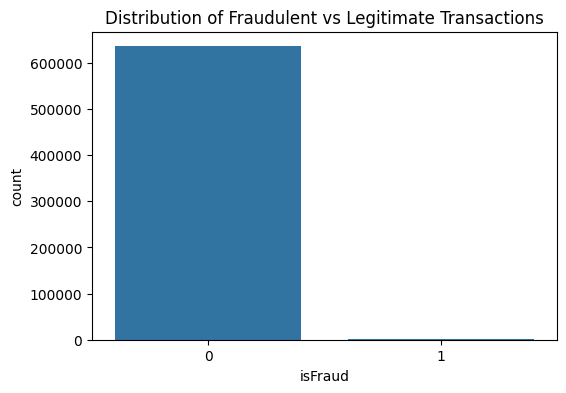

Fraud Percentage: 0.12840622259383713 %


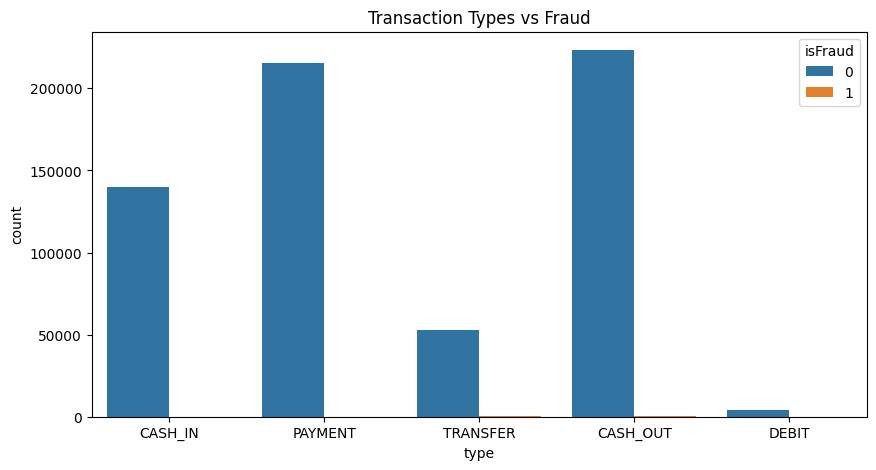

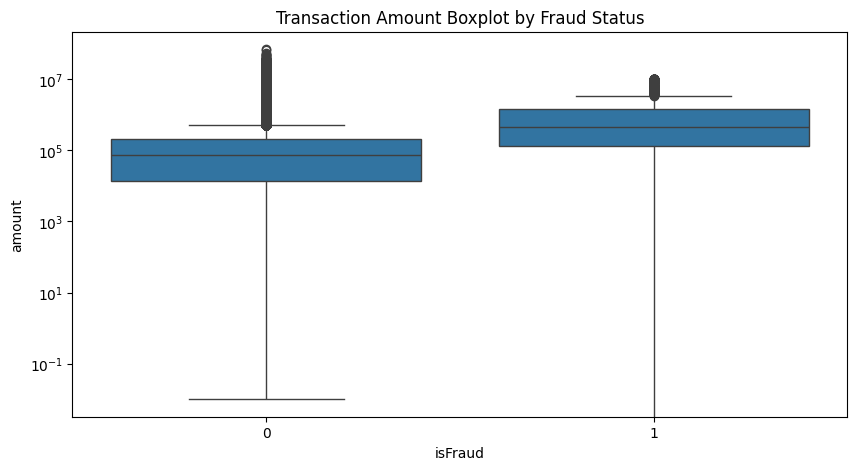

In [3]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Fraud distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='isFraud')
plt.title('Distribution of Fraudulent vs Legitimate Transactions')
plt.show()

print("Fraud Percentage:", (df['isFraud'].value_counts()[1] / len(df)) * 100, "%")

# Transaction types vs Fraud
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='type', hue='isFraud')
plt.title('Transaction Types vs Fraud')
plt.show()

# Amount distribution for fraud vs non-fraud
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='isFraud', y='amount')
plt.title('Transaction Amount Boxplot by Fraud Status')
plt.yscale('log')
plt.show()

## 3. Data Cleaning and Preprocessing
Dropping irrelevant columns, encoding categorical variables, and scaling numerical features.

In [4]:
# Drop identifiers as they are likely not useful for generalization
cols_to_drop = ['nameOrig', 'nameDest', 'isFlaggedFraud', 'step']
df_clean = df.drop(columns=cols_to_drop)

# One-hot encoding for transaction 'type'
df_clean = pd.get_dummies(df_clean, columns=['type'], drop_first=True)

# Separate features and target
X = df_clean.drop('isFraud', axis=1)
y = df_clean['isFraud']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for SHAP later
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(f"X_train shape: {X_train_scaled.shape}, y_train shape: {y_train.shape}")

X_train shape: (509009, 9), y_train shape: (509009,)


## 4. Handling Class Imbalance
Since fraud cases are highly imbalanced, we apply SMOTE (Synthetic Minority Over-sampling Technique) on the training set.

In [5]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE - Fraud counts: {sum(y_train==1)}, Non-Fraud: {sum(y_train==0)}")
print(f"After SMOTE - Fraud counts: {sum(y_train_sm==1)}, Non-Fraud: {sum(y_train_sm==0)}")

Before SMOTE - Fraud counts: 654, Non-Fraud: 508355
After SMOTE - Fraud counts: 508355, Non-Fraud: 508355


## 5. Model Training and Comparison
Training **six classifiers** and comparing them across ROC-AUC, F1, Precision, and Recall to select the best model for fraud detection.

| Model | Notes |
|---|---|
| Logistic Regression | Fast baseline |
| Decision Tree | Interpretable |
| Random Forest | Ensemble of trees |
| Gradient Boosting | Boosted ensemble |
| XGBoost | Optimised gradient boosting |
| LightGBM | Leaf-wise gradient boosting |

In [6]:
# Define all models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, C=0.1),
    'Decision Tree':       DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest':       RandomForestClassifier(n_estimators=50, random_state=42,
                                                    n_jobs=-1, max_depth=10),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=50, random_state=42,
                                                        max_depth=5),
}

if XGBOOST_AVAILABLE:
    models['XGBoost'] = XGBClassifier(
        n_estimators=50, random_state=42, n_jobs=-1, max_depth=5,
        eval_metric='logloss', verbosity=0
    )

if LGBM_AVAILABLE:
    models['LightGBM'] = LGBMClassifier(
        n_estimators=50, random_state=42, n_jobs=-1, max_depth=5, verbose=-1
    )

# Train all models and record metrics
results = {}
for name, model in models.items():
    print(f'Training {name}...', end=' ', flush=True)
    model.fit(X_train_sm, y_train_sm)
    y_pred      = model.predict(X_test_scaled)
    y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]
    results[name] = {
        'model':         model,
        'roc_auc':       roc_auc_score(y_test, y_pred_prob),
        'f1':            f1_score(y_test, y_pred),
        'precision':     precision_score(y_test, y_pred),
        'recall':        recall_score(y_test, y_pred),
        'predictions':   y_pred,
        'probabilities': y_pred_prob,
    }
    r = results[name]
    print(f"ROC-AUC={r['roc_auc']:.4f}  F1={r['f1']:.4f}  "
          f"Precision={r['precision']:.4f}  Recall={r['recall']:.4f}")

print('\nAll models trained!')

Training Logistic Regression... ROC-AUC=0.9871  F1=0.0388  Precision=0.0198  Recall=0.9693
Training Decision Tree... ROC-AUC=0.9901  F1=0.2273  Precision=0.1285  Recall=0.9816
Training Random Forest... ROC-AUC=0.9982  F1=0.1457  Precision=0.0787  Recall=0.9816
Training Gradient Boosting... ROC-AUC=0.9917  F1=0.1842  Precision=0.1016  Recall=0.9877
Training XGBoost... ROC-AUC=0.9989  F1=0.3975  Precision=0.2488  Recall=0.9877
Training LightGBM... ROC-AUC=0.9947  F1=0.1799  Precision=0.0990  Recall=0.9877

All models trained!


### 5.1 Model Comparison — Bar Charts & Heatmap
Visual comparison of all models across four performance metrics.

Model Performance Summary
                     ROC-AUC  F1 Score  Precision  Recall
Logistic Regression   0.9871    0.0388     0.0198  0.9693
Decision Tree         0.9901    0.2273     0.1285  0.9816
Random Forest         0.9982    0.1457     0.0787  0.9816
Gradient Boosting     0.9917    0.1842     0.1016  0.9877
XGBoost               0.9989    0.3975     0.2488  0.9877
LightGBM              0.9947    0.1799     0.0990  0.9877


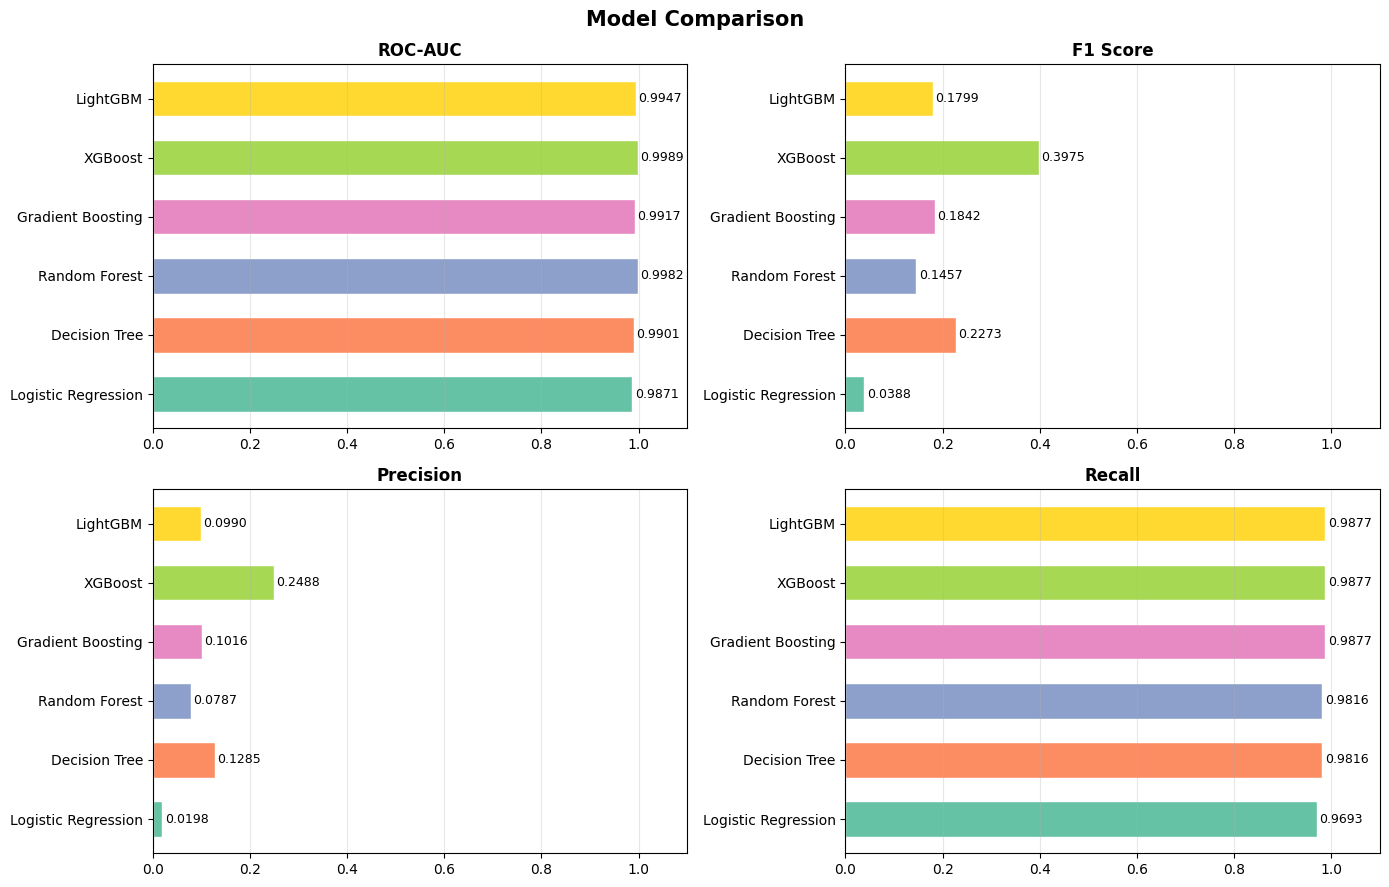

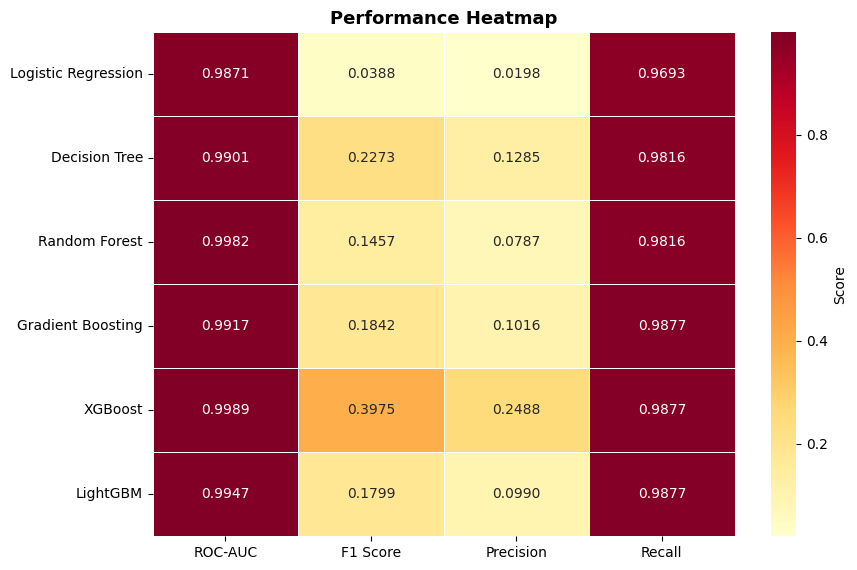


✅  Best Model  →  XGBoost
    ROC-AUC     : 0.998929
    F1 Score    : 0.397531
    Precision   : 0.248841
    Recall      : 0.987730


In [7]:
# Build summary table
comparison_df = pd.DataFrame(
    {name: {'ROC-AUC': r['roc_auc'], 'F1 Score': r['f1'],
             'Precision': r['precision'], 'Recall': r['recall']}
     for name, r in results.items()}
).T

print('Model Performance Summary')
print('=' * 65)
print(comparison_df.round(4).to_string())
print('=' * 65)

# Bar charts
metrics   = ['ROC-AUC', 'F1 Score', 'Precision', 'Recall']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Model Comparison', fontsize=15, fontweight='bold')
colors = plt.cm.Set2(range(len(comparison_df)))
for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    vals = comparison_df[metric]
    bars = ax.barh(comparison_df.index, vals, color=colors, edgecolor='white', height=0.6)
    ax.set_xlim(0, 1.1)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# Heatmap
plt.figure(figsize=(9, len(comparison_df) * 0.8 + 1))
sns.heatmap(comparison_df.astype(float), annot=True, fmt='.4f',
            cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': 'Score'})
plt.title('Performance Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Pick best model by ROC-AUC
best_model_name = comparison_df['ROC-AUC'].idxmax()
best_model      = results[best_model_name]['model']
print(f'\n✅  Best Model  →  {best_model_name}')
for m in metrics:
    print(f'    {m:<12}: {comparison_df.loc[best_model_name, m]:.6f}')

### 5.2 Detailed Evaluation of the Best Model
Full classification report and confusion matrix for the winning model.

=== Best Model: XGBoost ===

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    127090
           1       0.25      0.99      0.40       163

    accuracy                           1.00    127253
   macro avg       0.62      0.99      0.70    127253
weighted avg       1.00      1.00      1.00    127253

ROC-AUC Score: 0.998929


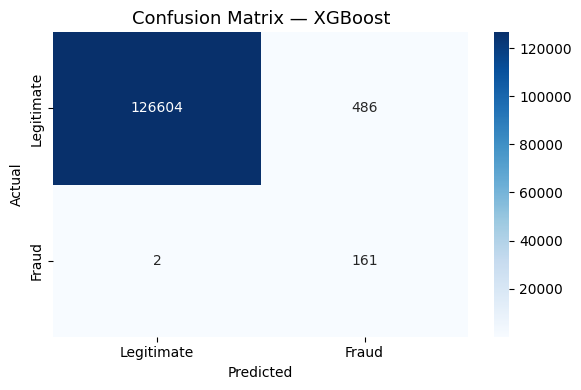

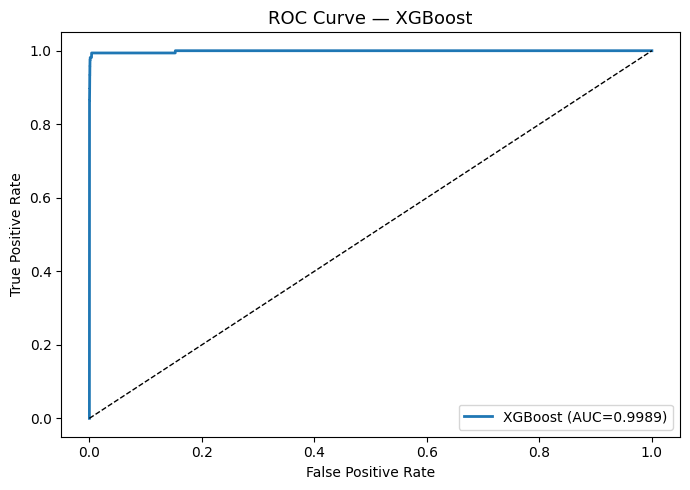

In [8]:
y_pred_best = results[best_model_name]['predictions']
y_prob_best = results[best_model_name]['probabilities']

print(f'=== Best Model: {best_model_name} ===')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_best))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob_best):.6f}')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title(f'Confusion Matrix — {best_model_name}', fontsize=13)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# ROC Curve for best model
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, lw=2, label=f'{best_model_name} (AUC={roc_auc_score(y_test, y_prob_best):.4f})')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve — {best_model_name}', fontsize=13)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 5.3  Save Best Model for Deployment
Serialises the trained model, scaler, feature names, and performance metrics so the Flask API can load them without re-training.

In [ ]:
import joblib, json, os

os.makedirs('models', exist_ok=True)

# Save artefacts
joblib.dump(best_model,                       'models/best_model.joblib')
joblib.dump(scaler,                           'models/scaler.joblib')
joblib.dump(X_train_scaled.columns.tolist(),  'models/feature_names.joblib')

meta = {
    'model_name': best_model_name,
    'roc_auc':    float(comparison_df.loc[best_model_name, 'ROC-AUC']),
    'f1_score':   float(comparison_df.loc[best_model_name, 'F1 Score']),
    'precision':  float(comparison_df.loc[best_model_name, 'Precision']),
    'recall':     float(comparison_df.loc[best_model_name, 'Recall']),
    'feature_names': X_train_scaled.columns.tolist(),
}
with open('models/model_metadata.json', 'w') as fh:
    json.dump(meta, fh, indent=2)

print('Saved to  models/')
print('  best_model.joblib')
print('  scaler.joblib')
print('  feature_names.joblib')
print('  model_metadata.json')
print(f'Model : {best_model_name}')
print(f'Features: {X_train_scaled.columns.tolist()}')


## 6. Explainable AI (SHAP)
Using SHAP values to explain feature importance and how features influence the model's predictions.

Computing SHAP values for: XGBoost


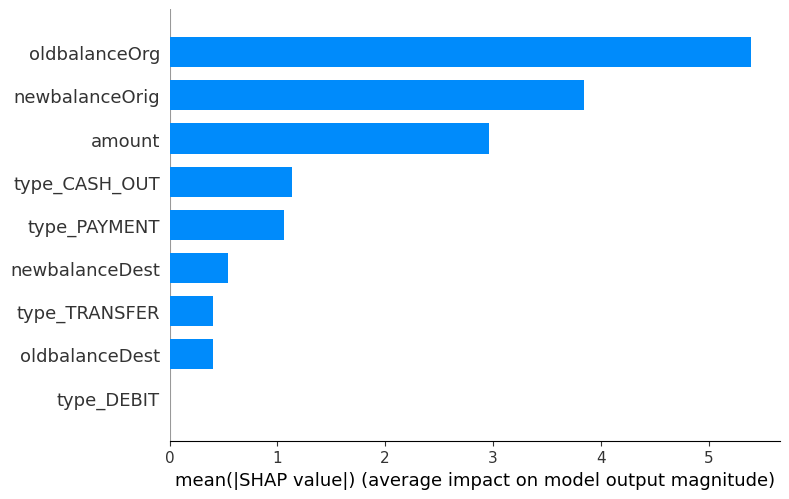

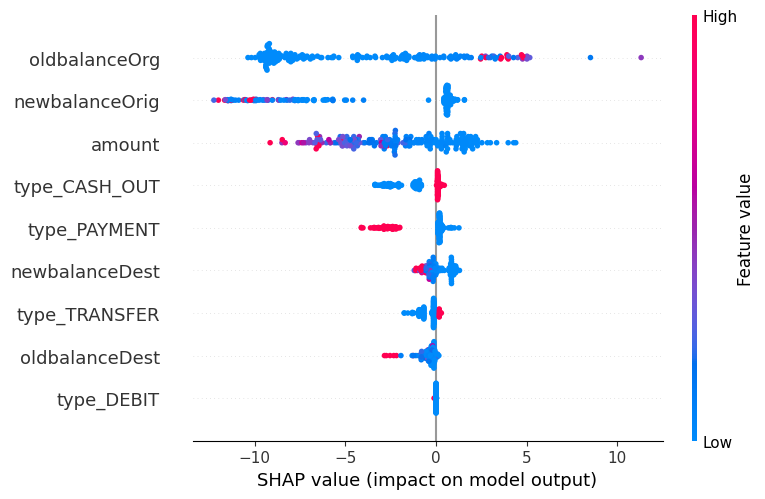

In [9]:
# Use the best model for SHAP explainability
print(f'Computing SHAP values for: {best_model_name}')

# Use a small sample for speed
X_shap_sample = X_test_scaled.sample(min(200, len(X_test_scaled)), random_state=42)

try:
    # TreeExplainer works for tree-based models
    explainer   = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_shap_sample)
    # For multi-output shap_values pick class-1
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values
except Exception:
    # Fallback: KernelExplainer for non-tree models
    bg = shap.sample(X_train_sm, 100, random_state=42)
    explainer   = shap.KernelExplainer(best_model.predict_proba, bg)
    shap_values = explainer.shap_values(X_shap_sample, nsamples=100)
    sv = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values

# Summary bar plot
plt.figure()
shap.summary_plot(sv, X_shap_sample, plot_type='bar',
                  title=f'SHAP Feature Importance — {best_model_name}', show=False)
plt.tight_layout()
plt.show()

# Beeswarm plot
plt.figure()
shap.summary_plot(sv, X_shap_sample,
                  title=f'SHAP Summary — {best_model_name}', show=False)
plt.tight_layout()
plt.show()